Mounted at /content/drive
Train 크기  : 81,513건
Validation : 9,057건

[전처리 완료]
  User-Item 행렬 크기 : (943, 1659)
  데이터 밀도         : 5.21%

[Significance Threshold 최적값 탐색 시작]
  Threshold 10 -> RMSE: 0.9202
  Threshold 20 -> RMSE: 0.9212
  Threshold 30 -> RMSE: 0.9221
  Threshold 40 -> RMSE: 0.9227
  Threshold 50 -> RMSE: 0.9239
  Threshold 60 -> RMSE: 0.9245

=> 최적 Threshold 선정: 10 (RMSE: 0.9202)

[유사도 행렬 계산 완료]
  user_sim_df       : (943, 943)
  item_sim_df       : (1659, 1659)
  item_sim_mc_df    : (1659, 1659)
  user_sim_weighted : (943, 943)

모델 비교 검증 시작...
  K=10 완료
  K=20 완료
  K=30 완료
  K=40 완료
  K=50 완료

          모델 성능 비교 결과 (Validation Set)
[RMSE]
 K  User_RMSE  Item_RMSE  ItemMC_RMSE  UserW_RMSE
10     0.9351     0.9730       0.9048      0.9338
20     0.9228     1.0391       0.8984      0.9215
30     0.9212     1.1218       0.9000      0.9202
40     0.9221     1.2035       0.9025      0.9209
50     0.9224     1.2662       0.9038      0.9212

[MAE]
 K  User_MAE  Item_MAE  ItemMC_MAE

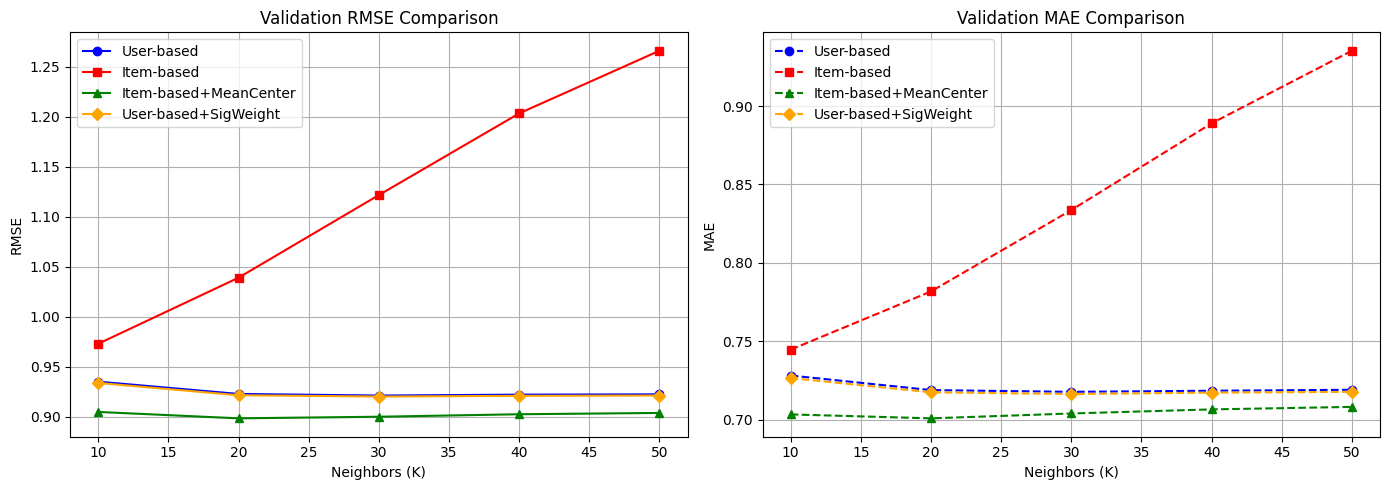


[랭킹 지표 평가 시작 (Top-10, 기준: 4.0점)]
Item-based MC  : Precision@10: 0.4515, Recall@10: 0.883, F1: 0.5975
User-based Weighted : Precision@10: 0.449, Recall@10: 0.8798, F1: 0.5946

최종 결론: ITEM_MC 모델 선정
- 최소 RMSE: 0.8984
- 최적의 K: 20

모델 저장 완료: model_final_v5.pkl


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error
import pickle
import math
import matplotlib.pyplot as plt
from google.colab import drive

# ──────────────────────────────────────────
# 0. 드라이브 마운트
# ──────────────────────────────────────────
drive.mount('/content/drive')
base_path = '/content/drive/MyDrive/Recommender_systems/ml-100k/'

# ──────────────────────────────────────────
# 1. 데이터 로드 및 Train / Validation 분할
# ──────────────────────────────────────────
train_full = pd.read_csv(base_path + 'ua.base', sep='\t',
                         names=['user_id', 'item_id', 'rating', 'ts'])
train_data, val_data = train_test_split(train_full, test_size=0.1, random_state=42)

print(f"Train 크기  : {len(train_data):,}건")
print(f"Validation : {len(val_data):,}건")

# ──────────────────────────────────────────
# 2. 전처리
# ──────────────────────────────────────────
# 2-1. User-Item 평점 행렬
train_matrix = train_data.pivot(index='user_id', columns='item_id', values='rating')

# 2-2. 사용자 평균 평점
user_mean = train_matrix.mean(axis=1)

# 2-3. Mean-Centering (사용자 편향 제거)
#      NaN → 0 : 미평가 아이템을 '평균으로부터의 편차 없음(중립)'으로 해석
train_matrix_centered = train_matrix.sub(user_mean, axis=0).fillna(0)

# 2-4. 아이템 평균 평점 (Item-based Mean-Centering용)
#      아이템마다 평점을 부여하는 사용자 기준이 다름을 보정
item_mean = train_matrix.mean(axis=0)
train_matrix_item_centered = train_matrix.sub(item_mean, axis=1).fillna(0)

print("\n[전처리 완료]")
print(f"  User-Item 행렬 크기 : {train_matrix.shape}")
print(f"  데이터 밀도         : {train_matrix.notna().sum().sum() / train_matrix.size * 100:.2f}%")

# ──────────────────────────────────────────
# 3. 유사도 행렬 계산
# ──────────────────────────────────────────
# 3-1. User-based 유사도 (Adjusted Cosine: Mean-Centering 후 코사인)
user_sim_df = pd.DataFrame(
    cosine_similarity(train_matrix_centered),
    index=train_matrix.index,
    columns=train_matrix.index
)

# 3-2. Item-based 유사도 (기존 방식: 사용자 Mean-Centering 후 아이템 간 코사인)
item_sim_df = pd.DataFrame(
    cosine_similarity(train_matrix_centered.T),
    index=train_matrix.columns,
    columns=train_matrix.columns
)

# 3-3. Item-based 유사도 (아이템 Mean-Centering 적용)
#      각 아이템의 평균 평점을 빼서 아이템 편향도 제거
item_sim_mc_df = pd.DataFrame(
    cosine_similarity(train_matrix_item_centered.T),
    index=train_matrix.columns,
    columns=train_matrix.columns
)

# 3-4. Significance Weighting 행렬 (사용자 쌍별 공통 평점 아이템 수)
#      공통 평점이 적은 사용자 쌍의 유사도를 감쇠시켜 신뢰성 보정
#      weight = min(공통 평점 수, threshold) / threshold
rating_mask = (train_matrix > 0).astype(int).fillna(0)
co_rating_counts = rating_mask.dot(rating_mask.T).astype(float)

# 실험할 Threshold 후보군
threshold_candidates = [10, 20, 30, 40, 50, 60]
th_results = []

print("\n[Significance Threshold 최적값 탐색 시작]")

# 실험용 임시 예측 함수 (현재 루프의 가중 유사도 행렬을 인자로 받음)
def predict_th_test(user_id, item_id, k, sim_matrix):
    if user_id not in sim_matrix.index or item_id not in train_matrix.columns:
        return user_mean.get(user_id, 3.0)
    sim_scores = sim_matrix[user_id]
    rated_users = train_matrix[item_id][train_matrix[item_id] > 0].index
    top_k = sim_scores[rated_users].sort_values(ascending=False).head(k)
    if top_k.abs().sum() == 0:
        return user_mean.get(user_id, 3.0)
    pred = user_mean[user_id] + (
        np.dot(top_k, train_matrix_centered.loc[top_k.index, item_id]) / top_k.abs().sum()
    )
    return max(1.0, min(5.0, pred))

# 후보군 루프
for th in threshold_candidates:
    # 현재 TH에 따른 가중치 및 유사도 행렬 계산
    current_weight = co_rating_counts.clip(upper=th) / th
    temp_sim_weighted = user_sim_df * current_weight

    # Validation Set에 대해 예측 수행 (기준 K=30)
    th_preds = [predict_th_test(u, i, 30, temp_sim_weighted)
                for u, i in zip(val_data['user_id'], val_data['item_id'])]

    current_rmse = math.sqrt(mean_squared_error(val_data['rating'], th_preds))
    th_results.append({'threshold': th, 'rmse': current_rmse})
    print(f"  Threshold {th:2d} -> RMSE: {current_rmse:.4f}")

# 최적의 Threshold 선택
best_th_idx = pd.DataFrame(th_results)['rmse'].idxmin()
SIGNIFICANCE_THRESHOLD = threshold_candidates[best_th_idx]

print(f"\n=> 최적 Threshold 선정: {SIGNIFICANCE_THRESHOLD} (RMSE: {th_results[best_th_idx]['rmse']:.4f})")

# 최종 Significance Weighting 적용
significance_weight = (co_rating_counts.clip(upper=SIGNIFICANCE_THRESHOLD)
                       / SIGNIFICANCE_THRESHOLD)
user_sim_weighted_df = user_sim_df * significance_weight


# Significance Weighting 적용: 유사도 × 가중치
user_sim_weighted_df = user_sim_df * significance_weight

print("\n[유사도 행렬 계산 완료]")
print(f"  user_sim_df       : {user_sim_df.shape}")
print(f"  item_sim_df       : {item_sim_df.shape}")
print(f"  item_sim_mc_df    : {item_sim_mc_df.shape}")
print(f"  user_sim_weighted : {user_sim_weighted_df.shape}")

# ──────────────────────────────────────────
# 4. 예측 함수 4종
# ──────────────────────────────────────────

# [모델 1] User-based CF (기본)
def predict_user(user_id, item_id, k=30):
    """
    사용자 간 Adjusted Cosine 유사도 기반 예측.
    Mean-Centering으로 사용자 편향 제거 후 가중합 계산.
    """
    if user_id not in user_sim_df.index or item_id not in train_matrix.columns:
        return user_mean.get(user_id, 3.0)
    sim_scores = user_sim_df[user_id]
    rated_users = train_matrix[item_id][train_matrix[item_id] > 0].index
    top_k = sim_scores[rated_users].sort_values(ascending=False).head(k)
    if top_k.abs().sum() == 0:
        return user_mean[user_id]
    pred = user_mean[user_id] + (
        np.dot(top_k, train_matrix_centered.loc[top_k.index, item_id])
        / top_k.abs().sum()
    )
    return max(1.0, min(5.0, pred))


# [모델 2] Item-based CF (기존, 사용자 Mean-Centering)
def predict_item(user_id, item_id, k=30):
    """
    아이템 간 코사인 유사도 기반 예측.
    사용자 Mean-Centering 적용 행렬에서 아이템 유사도 계산.
    예측은 원본 평점의 가중합 사용.
    """
    if item_id not in item_sim_df.index or user_id not in train_matrix.index:
        return user_mean.get(user_id, 3.0)
    sim_scores = item_sim_df[item_id]
    rated_items = train_matrix.loc[user_id][train_matrix.loc[user_id] > 0].index
    top_k = sim_scores[rated_items].sort_values(ascending=False).head(k)
    if top_k.abs().sum() == 0:
        return user_mean[user_id]
    pred = np.dot(top_k, train_matrix.loc[user_id, top_k.index]) / top_k.abs().sum()
    return max(1.0, min(5.0, pred))


# [모델 3] Item-based CF + Item Mean-Centering
def predict_item_mc(user_id, item_id, k=30):
    """
    아이템 편향까지 제거한 Item-based CF.
    각 아이템의 평균 평점을 빼고 유사도를 계산하여
    인기 아이템 편향 문제를 추가로 보정.
    예측 시 아이템 평균을 복원하여 최종 평점 산출.
    """
    if item_id not in item_sim_mc_df.index or user_id not in train_matrix.index:
        return user_mean.get(user_id, 3.0)
    sim_scores = item_sim_mc_df[item_id]
    rated_items = train_matrix.loc[user_id][train_matrix.loc[user_id] > 0].index
    top_k = sim_scores[rated_items].sort_values(ascending=False).head(k)
    if top_k.abs().sum() == 0:
        return user_mean.get(user_id, 3.0)
    # Mean-Centering된 평점의 가중합 후 아이템 평균 복원
    centered_ratings = train_matrix_item_centered.loc[user_id, top_k.index]
    pred = item_mean[item_id] + (
        np.dot(top_k, centered_ratings) / top_k.abs().sum()
    )
    return max(1.0, min(5.0, pred))


# [모델 4] Weighted User-based CF (Significance Weighting)
def predict_user_weighted(user_id, item_id, k=30):
    """
    Significance Weighting 적용 User-based CF.
    공통 평점 아이템 수가 적은 사용자 쌍의 유사도에
    감쇠 계수(0~1)를 곱해 신뢰성이 낮은 유사도를 하향 보정.
    threshold=50: 공통 평점 50개 이상이면 감쇠 없음.
    """
    if user_id not in user_sim_weighted_df.index or item_id not in train_matrix.columns:
        return user_mean.get(user_id, 3.0)
    sim_scores = user_sim_weighted_df[user_id]
    rated_users = train_matrix[item_id][train_matrix[item_id] > 0].index
    top_k = sim_scores[rated_users].sort_values(ascending=False).head(k)
    if top_k.abs().sum() == 0:
        return user_mean[user_id]
    pred = user_mean[user_id] + (
        np.dot(top_k, train_matrix_centered.loc[top_k.index, item_id])
        / top_k.abs().sum()
    )
    return max(1.0, min(5.0, pred))


# ──────────────────────────────────────────
# 5. K별 모델 성능 비교 실험
# ──────────────────────────────────────────
k_list = [10, 20, 30, 40, 50]
results = []

print("\n모델 비교 검증 시작...")
for k in k_list:
    u_preds    = [predict_user(u, i, k)          for u, i in zip(val_data['user_id'], val_data['item_id'])]
    i_preds    = [predict_item(u, i, k)          for u, i in zip(val_data['user_id'], val_data['item_id'])]
    imc_preds  = [predict_item_mc(u, i, k)       for u, i in zip(val_data['user_id'], val_data['item_id'])]
    uw_preds   = [predict_user_weighted(u, i, k) for u, i in zip(val_data['user_id'], val_data['item_id'])]

    def rmse(y, p): return math.sqrt(mean_squared_error(y, p))
    def mae(y, p):  return mean_absolute_error(y, p)
    y = val_data['rating']

    results.append({
        'K'            : k,
        'User_RMSE'    : round(rmse(y, u_preds),   4),
        'Item_RMSE'    : round(rmse(y, i_preds),   4),
        'ItemMC_RMSE'  : round(rmse(y, imc_preds), 4),
        'UserW_RMSE'   : round(rmse(y, uw_preds),  4),
        'User_MAE'     : round(mae(y, u_preds),    4),
        'Item_MAE'     : round(mae(y, i_preds),    4),
        'ItemMC_MAE'   : round(mae(y, imc_preds),  4),
        'UserW_MAE'    : round(mae(y, uw_preds),   4),
    })
    print(f"  K={k} 완료")

# ──────────────────────────────────────────
# 6. 결과 출력
# ──────────────────────────────────────────
res_df = pd.DataFrame(results)

print("\n" + "="*70)
print("          모델 성능 비교 결과 (Validation Set)")
print("="*70)
rmse_cols = ['K','User_RMSE','Item_RMSE','ItemMC_RMSE','UserW_RMSE']
mae_cols  = ['K','User_MAE', 'Item_MAE', 'ItemMC_MAE', 'UserW_MAE']
print("[RMSE]")
print(res_df[rmse_cols].to_string(index=False))
print("\n[MAE]")
print(res_df[mae_cols].to_string(index=False))
print("="*70)

# ──────────────────────────────────────────
# 7. 시각화
# ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE
axes[0].plot(res_df['K'], res_df['User_RMSE'],   marker='o', label='User-based',           color='blue')
axes[0].plot(res_df['K'], res_df['Item_RMSE'],   marker='s', label='Item-based',            color='red')
axes[0].plot(res_df['K'], res_df['ItemMC_RMSE'], marker='^', label='Item-based+MeanCenter', color='green')
axes[0].plot(res_df['K'], res_df['UserW_RMSE'],  marker='D', label='User-based+SigWeight',  color='orange')
axes[0].set_title('Validation RMSE Comparison')
axes[0].set_xlabel('Neighbors (K)')
axes[0].set_ylabel('RMSE')
axes[0].legend()
axes[0].grid(True)

# MAE
axes[1].plot(res_df['K'], res_df['User_MAE'],   marker='o', ls='--', label='User-based',           color='blue')
axes[1].plot(res_df['K'], res_df['Item_MAE'],   marker='s', ls='--', label='Item-based',            color='red')
axes[1].plot(res_df['K'], res_df['ItemMC_MAE'], marker='^', ls='--', label='Item-based+MeanCenter', color='green')
axes[1].plot(res_df['K'], res_df['UserW_MAE'],  marker='D', ls='--', label='User-based+SigWeight',  color='orange')
axes[1].set_title('Validation MAE Comparison')
axes[1].set_xlabel('Neighbors (K)')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# ──────────────────────────────────────────
# 8. 최적 모델 선정 및 저장
# ──────────────────────────────────────────
# ──────────────────────────────────────────
# 8. 랭킹 기반 성능 평가 (Precision, Recall, F1)
# ──────────────────────────────────────────
def evaluate_ranking_metrics(val_data, predict_func, k=10, rating_threshold=4.0):
    """
    강의 자료 43p 기준: 정밀도, 재현율, F1-score 계산
    - rating_threshold: 실제 평점이 이 점수 이상이면 'Positive(좋아함)'로 간주
    """
    user_precisions = []
    user_recalls = []

    # 실제 평점이 threshold 이상인 데이터만 'Relevant'로 분류
    # 검증셋 내 각 사용자별로 루프
    for user_id in val_data['user_id'].unique():
        user_actual = val_data[val_data['user_id'] == user_id]

        # 1. 사용자가 실제로 좋아한 아이템 (Ground Truth)
        relevant_items = set(user_actual[user_actual['rating'] >= rating_threshold]['item_id'])
        if len(relevant_items) == 0: continue  # 좋아하는 아이템이 없는 사용자는 평가 제외

        # 2. 모델의 예측 상위 K개 추출
        item_ids = user_actual['item_id'].tolist()
        # 해당 사용자의 검증셋 내 아이템들에 대해 점수 예측
        preds = [predict_func(user_id, i_id, k=30) for i_id in item_ids]
        pred_series = pd.Series(preds, index=item_ids).sort_values(ascending=False)
        top_k_recommended = set(pred_series.head(k).index)

        # 3. Hit(교집합) 계산
        hits = len(relevant_items & top_k_recommended)

        # 4. 개별 지표 계산
        precision = hits / k
        recall = hits / len(relevant_items)

        user_precisions.append(precision)
        user_recalls.append(recall)

    avg_precision = np.mean(user_precisions)
    avg_recall = np.mean(user_recalls)

    # F1-score 계산 (조화 평균)
    if (avg_precision + avg_recall) > 0:
        f1_score = 2 * (avg_precision * avg_recall) / (avg_precision + avg_recall)
    else:
        f1_score = 0.0

    return round(avg_precision, 4), round(avg_recall, 4), round(f1_score, 4)

print("\n[랭킹 지표 평가 시작 (Top-10, 기준: 4.0점)]")

# 최적 모델로 선정된 후보들에 대해 랭킹 지표 추가 측정
# 여기서는 가장 성능이 좋았던 ITEM_MC와 가중치 적용된 UserW를 비교 예시로 듭니다.
p_imc, r_imc, f1_imc = evaluate_ranking_metrics(val_data, predict_item_mc, k=10)
p_uw, r_uw, f1_uw = evaluate_ranking_metrics(val_data, predict_user_weighted, k=10)

print(f"Item-based MC  : Precision@10: {p_imc}, Recall@10: {r_imc}, F1: {f1_imc}")
print(f"User-based Weighted : Precision@10: {p_uw}, Recall@10: {r_uw}, F1: {f1_uw}")

# ──────────────────────────────────────────
# 9. 최종 모델 선정 및 저장
# ──────────────────────────────────────────
# 1. RMSE 기준 최적 모델 정보 요약
model_rmse_map = {
    'user': res_df['User_RMSE'].min(),
    'item': res_df['Item_RMSE'].min(),
    'item_mc': res_df['ItemMC_RMSE'].min(),
    'user_w': res_df['UserW_RMSE'].min(),
}

# 2. 최적 모델 종류 결정
best_kind = min(model_rmse_map, key=model_rmse_map.get)
best_rmse = model_rmse_map[best_kind]

kind_to_col_map = {
    'user': 'User_RMSE',
    'item': 'Item_RMSE',
    'item_mc': 'ItemMC_RMSE',
    'user_w': 'UserW_RMSE'
}

# 4. 최적의 K값 추출
target_col = kind_to_col_map[best_kind]
best_k_idx = res_df[target_col].idxmin()
best_k = res_df.loc[best_k_idx, 'K']

print(f"\n" + "="*50)
print(f"최종 결론: {best_kind.upper()} 모델 선정")
print(f"- 최소 RMSE: {best_rmse:.4f}")
print(f"- 최적의 K: {best_k}")
print("="*50)

# 5. 모델 데이터 저장 (모든 필요 데이터 포함)
model_data = {
    'train_matrix': train_matrix.fillna(0),
    'train_matrix_centered': train_matrix_centered,
    'train_matrix_item_centered': train_matrix_item_centered, # 이 행렬이 있어야 테스트 코드 에러가 안 납니다.
    'user_sim': user_sim_df,
    'user_sim_weighted': user_sim_weighted_df,
    'item_sim': item_sim_df,
    'item_sim_mc': item_sim_mc_df,
    'user_mean': user_mean,
    'item_mean': item_mean,
    'best_k': int(best_k),
    'best_kind': best_kind,
    'significance_threshold': SIGNIFICANCE_THRESHOLD,
    'val_results': res_df,
    'ranking_metrics': {
        'precision': p_imc if best_kind == 'item_mc' else p_uw,
        'recall': r_imc if best_kind == 'item_mc' else r_uw,
        'f1': f1_imc if best_kind == 'item_mc' else f1_uw
    }
}

with open(base_path + 'model_final_v5.pkl', 'wb') as f:
    pickle.dump(model_data, f)
print(f"\n모델 저장 완료: model_final_v5.pkl")